<a href="https://colab.research.google.com/github/heyanugrah/pytorch/blob/main/nn_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [82]:
from torch import nn
import torch
import matplotlib.pyplot as plt

In [83]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))
    self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float32))

  def forward(self,x:torch.Tensor)->torch.Tensor:
    return x * self.weight + self.bias

In [84]:
torch.manual_seed(42)

In [85]:
linearModel = LinearRegressionModel()

In [86]:
linearModel

LinearRegressionModel()

In [87]:
list(linearModel.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [88]:
linearModel.state_dict() #list named parameter

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [89]:
import numpy as np
torch.manual_seed(42)

# Create *known* parameters
weight = 0.7
bias = 0.3

# Create data
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Split data into training and testing sets

Let's create a training set and a testing set. The model will learn patterns from the training data (`X_train`, `y_train`) and then be evaluated on the testing data (`X_test`, `y_test`).

In [90]:
# Create train and test splits
train_split = int(0.8 * len(X)) # 80% of data for training
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [91]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

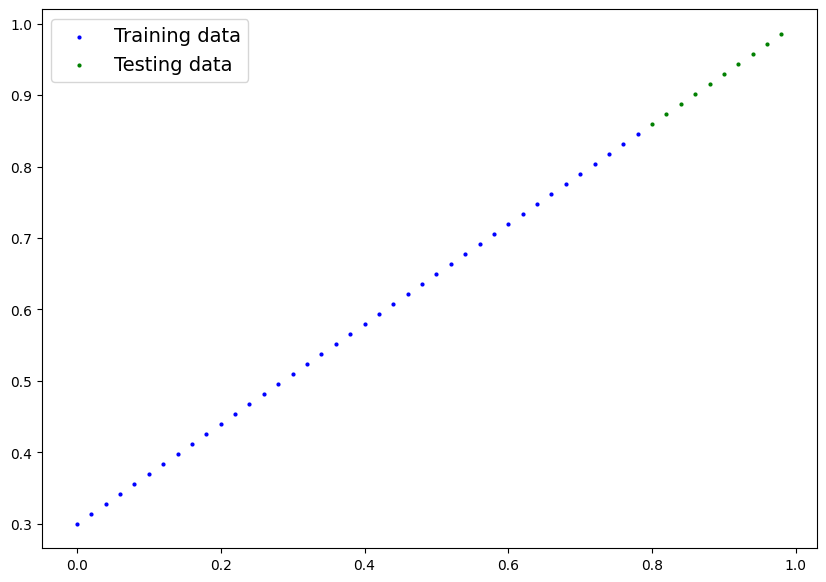

In [92]:
plot_predictions()

In [93]:
#make prediction with model

In [94]:
X_test , y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [95]:
##Model prediction example

#with torch.inference_mode():
  #y_pred = linearModel(X_test)

with torch.no_grad():
  y_pred = linearModel(X_test)

In [96]:
y_pred

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [97]:
y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

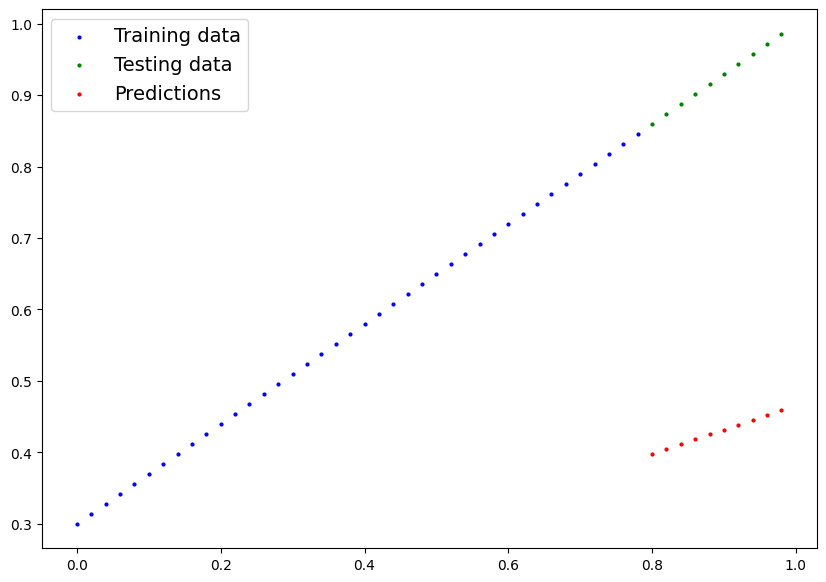

In [98]:
plot_predictions(predictions=y_pred)

In [99]:
linearModel.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [100]:
#set up an optimizer
dir(torch.optim)

['ASGD',
 'Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'LBFGS',
 'Muon',
 'NAdam',
 'Optimizer',
 'RAdam',
 'RMSprop',
 'Rprop',
 'SGD',
 'SparseAdam',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_adafactor',
 '_functional',
 '_muon',
 'lr_scheduler',
 'swa_utils']

In [101]:
#setup a loss function
loss_fn = nn.L1Loss()

In [102]:
import torch.optim as optim

#set up optimizer (update weights and bias)
optimizer = optim.SGD(params=linearModel.parameters(), lr=0.01)

In [103]:
#build a training loop and testing loop

In [104]:
### training loop
epochs = 10

# Create empty loss lists to track values
epoch_count = []
loss_values = []
test_loss_values = [] # New list to store test loss
weight_history = []
bias_history = []

for epoch in range(epochs):
  #training mode
  linearModel.train()

  #1 forward propogation
  y_pred = linearModel(X_train)
  print(f"Epoch {epoch+1}:")
  print("  Weights (before backward pass):", linearModel.weight)
  print("  Bias (before backward pass):", linearModel.bias)

  #2 calculate the loss
  loss = loss_fn(y_pred,y_train)
  print(f"  Loss: {loss.item():.4f}")

  # Store the loss value
  epoch_count.append(epoch)
  loss_values.append(loss.item())

  #3 optimizer zero grad
  optimizer.zero_grad()

  #4 back propogation
  loss.backward()
  print("  Weights Gradient:", linearModel.weight.grad)
  print("  Bias Gradient:", linearModel.bias.grad)

  #5 step the optimizer perform gradient descent
  optimizer.step()
  print("  Weights (after optimizer step):", linearModel.weight)
  print("  Bias (after optimizer step):", linearModel.bias)

  # Store weight and bias after update
  weight_history.append(linearModel.weight.item())
  bias_history.append(linearModel.bias.item())

  # Testing loop (evaluation mode)
  linearModel.eval() #turn off gradient tracking
  with torch.inference_mode():
    test_pred = linearModel(X_test)
    test_loss = loss_fn(test_pred, y_test)
    test_loss_values.append(test_loss.item())
    print(f"  Test Loss: {test_loss.item():.4f}")

  print("-" * 30)


Epoch 1:
  Weights (before backward pass): Parameter containing:
tensor([0.3367], requires_grad=True)
  Bias (before backward pass): Parameter containing:
tensor([0.1288], requires_grad=True)
  Loss: 0.3129
  Weights Gradient: tensor([-0.3900])
  Bias Gradient: tensor([-1.])
  Weights (after optimizer step): Parameter containing:
tensor([0.3406], requires_grad=True)
  Bias (after optimizer step): Parameter containing:
tensor([0.1388], requires_grad=True)
  Test Loss: 0.4811
------------------------------
Epoch 2:
  Weights (before backward pass): Parameter containing:
tensor([0.3406], requires_grad=True)
  Bias (before backward pass): Parameter containing:
tensor([0.1388], requires_grad=True)
  Loss: 0.3014
  Weights Gradient: tensor([-0.3900])
  Bias Gradient: tensor([-1.])
  Weights (after optimizer step): Parameter containing:
tensor([0.3445], requires_grad=True)
  Bias (after optimizer step): Parameter containing:
tensor([0.1488], requires_grad=True)
  Test Loss: 0.4676
-----------

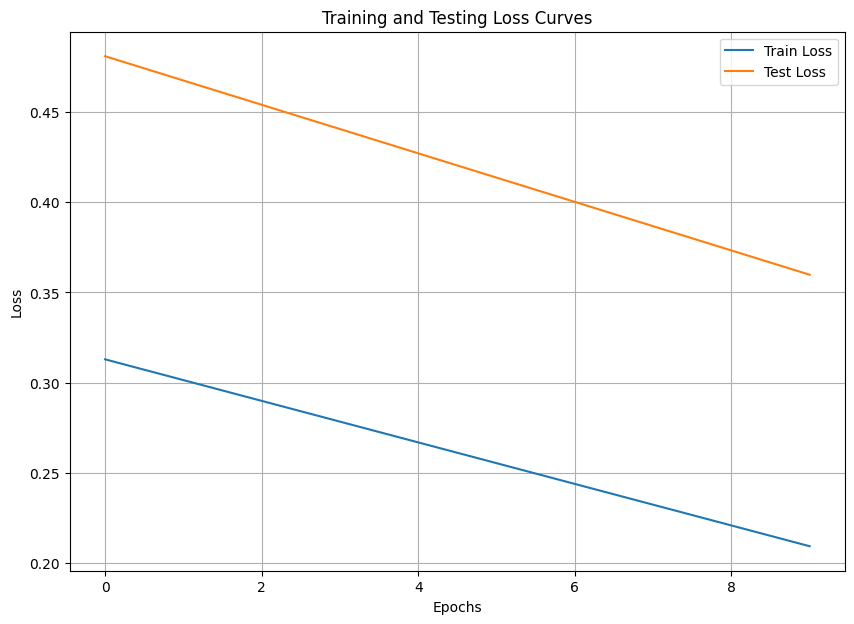

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.plot(epoch_count, loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.title("Training and Testing Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

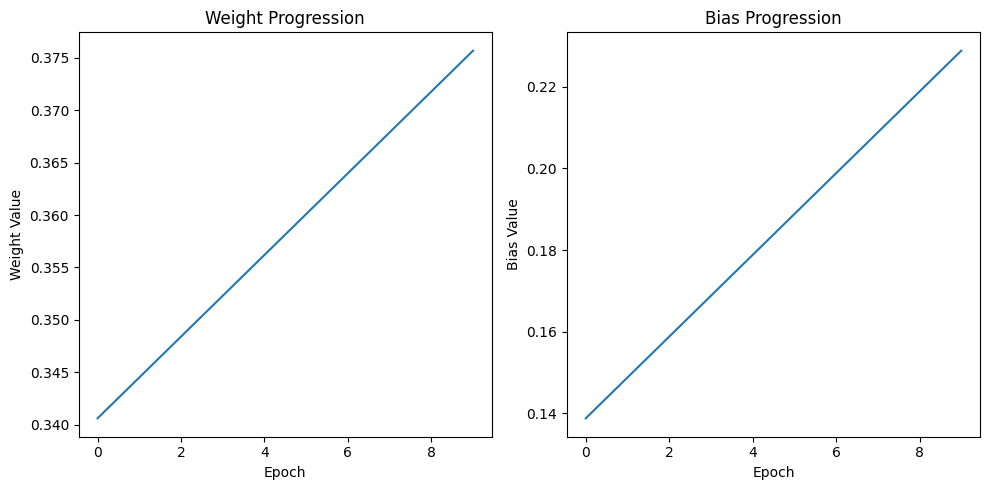

In [106]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot Weight History
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(epoch_count, weight_history)
plt.title("Weight Progression")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")

# Plot Bias History
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(epoch_count, bias_history)
plt.title("Bias Progression")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")

plt.tight_layout()
plt.show()

In [107]:
### testing loop

print("\n" + "=" * 30)
print("Final Model Parameters (after training):")
print("  Final Weights:", linearModel.weight)
print("  Final Bias:", linearModel.bias)
print("=" * 30)


Final Model Parameters (after training):
  Final Weights: Parameter containing:
tensor([0.3757], requires_grad=True)
  Final Bias: Parameter containing:
tensor([0.2288], requires_grad=True)


tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])
Final Test Loss: 0.3598


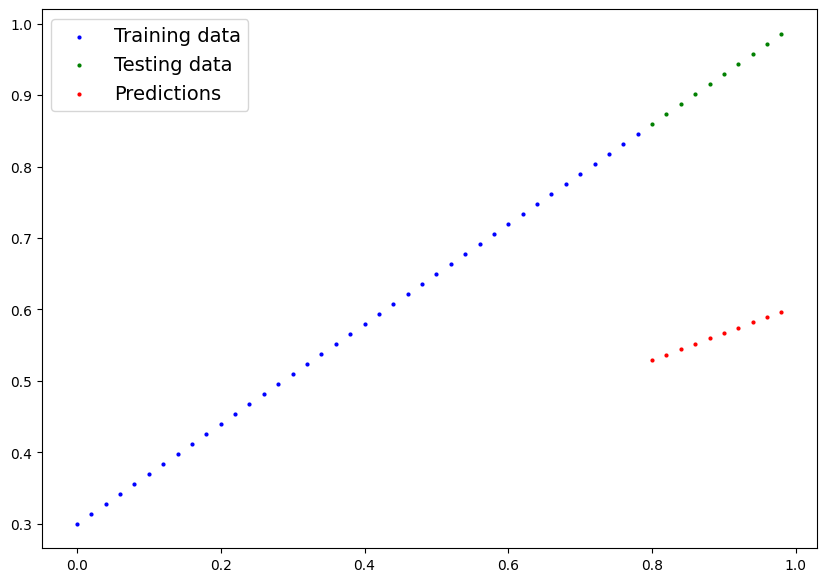

In [108]:
##testing
print(X_test)
# The 'epochs' loop here is redundant for evaluation since the model parameters don't change.
# We can simply calculate the test loss once.
# epochs = 100

with torch.inference_mode():
  #do the forward pass
  test_pred = linearModel(X_test)

  #calculate the loss
  test_loss = loss_fn(test_pred,y_test)
  print(f"Final Test Loss: {test_loss:.4f}")

plot_predictions(predictions=test_pred.cpu())

### Other Regression Metrics: Mean Squared Error (MSE)

While Mean Absolute Error (MAE) (what `nn.L1Loss()` calculates) is excellent, Mean Squared Error (MSE) is another popular choice. MSE measures the average of the squares of the errors, which means it gives higher weight to larger errors. Let's calculate it.

In [109]:
loss_fn_mse = nn.MSELoss()

with torch.inference_mode():
  # The test_pred and y_test are already computed in the previous cell
  # We just need to calculate the MSE loss.
  test_loss_mse = loss_fn_mse(test_pred, y_test)
  print(f"Mean Squared Error (MSE) on Test Set: {test_loss_mse:.4f}")

Mean Squared Error (MSE) on Test Set: 0.1298


Comparing the MAE (from `nn.L1Loss`) and MSE gives you a good sense of your model's performance. Lower values for both indicate a better fit. You can also consider metrics like $R^2$ (R-squared) for a more interpretable measure of how much variance your model explains.

In [112]:
linearModel.state_dict()
# This output shows the final learned weight and bias of the model after training.

OrderedDict([('weight', tensor([0.3757])), ('bias', tensor([0.2288]))])

In [113]:
#saving a model in pytorch

In [117]:
import torch
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "linear_regression_model.pt"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=linearModel.state_dict(), f=MODEL_SAVE_PATH)

# To verify, print the saved state_dict
print(f"\nSaved model state_dict: {MODEL_SAVE_PATH}")
print(linearModel.state_dict())

Saving model to: models/linear_regression_model.pt

Saved model state_dict: models/linear_regression_model.pt
OrderedDict({'weight': tensor([0.3757]), 'bias': tensor([0.2288])})


In [116]:
# To load a saved state_dict, we have to instantiate a new instance of our model class
loaded_model = LinearRegressionModel()

# Load the saved state_dict into the new model instance
loaded_model.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# 4. Make predictions with the loaded model to verify it works
loaded_model.eval() # Set the model to evaluation mode
with torch.inference_mode():
    loaded_model_preds = loaded_model(X_test)

# Compare predictions of original model and loaded model
print("Predictions from original model:")
print(test_pred) # Use test_pred (predictions on X_test) for comparison
print("\nPredictions from loaded model:")
print(loaded_model_preds)

# Are the predictions the same?
print("\nAre predictions from original and loaded model the same?")
print(torch.isclose(test_pred, loaded_model_preds).all())

# Check the loaded model's parameters
print("\nLoaded model's state_dict:")
print(loaded_model.state_dict())

Predictions from original model:
tensor([[0.5294],
        [0.5369],
        [0.5444],
        [0.5519],
        [0.5594],
        [0.5669],
        [0.5744],
        [0.5820],
        [0.5895],
        [0.5970]])

Predictions from loaded model:
tensor([[0.5294],
        [0.5369],
        [0.5444],
        [0.5519],
        [0.5594],
        [0.5669],
        [0.5744],
        [0.5820],
        [0.5895],
        [0.5970]])

Are predictions from original and loaded model the same?
tensor(True)

Loaded model's state_dict:
OrderedDict({'weight': tensor([0.3757]), 'bias': tensor([0.2288])})
